# TP1 - Neurona Artificial

En este trabajo práctico se implementa una neurona artificial simple y se analiza su comportamiento en distintas dimensiones y con diferentes funciones de activación.

Se evaluará su respuesta en 1D, 2D y 3D, y se compararán distintas funciones de activación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Inicialización
def initialize_neuron(input_size):
    weights = np.random.rand(input_size)
    bias = np.random.rand(1)
    return weights, bias

# Funciones de activación
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def step(x):
    return np.where(x >= 0, 1, 0)

# Forward pass
def forward_pass(inputs, weights, bias, activation="sigmoid"):
    z = np.dot(inputs, weights) + bias
    
    if activation == "sigmoid":
        return sigmoid(z)
    elif activation == "relu":
        return relu(z)
    elif activation == "tanh":
        return tanh(z)
    elif activation == "step":
        return step(z)


## 1. Análisis en una dimensión (1D)

Se analiza el comportamiento de la neurona para inputs en el intervalo [0,1]

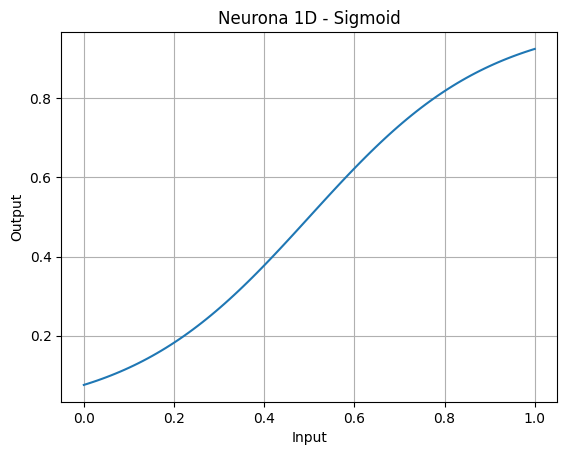

In [3]:
x_values = np.linspace(0, 1, 100)

weights = np.array([5])
bias = np.array([-2.5])

outputs = [forward_pass([x], weights, bias, activation="sigmoid")[0] for x in x_values]

plt.figure()
plt.plot(x_values, outputs)
plt.title("Neurona 1D - Sigmoid")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()

plt.savefig("../results/neuron_1D_sigmoid.png")
plt.show()

## Comparación de funciones de activación

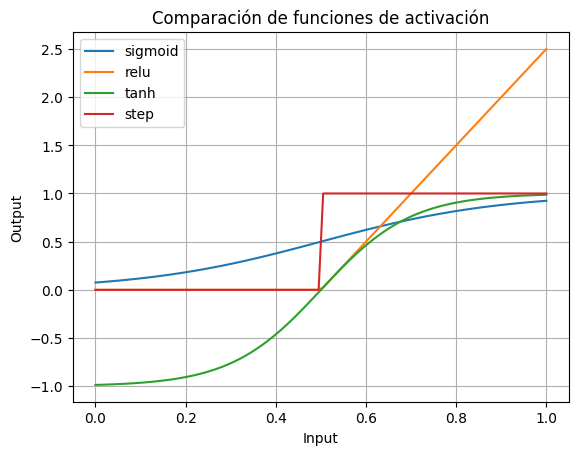

In [4]:
activations = ["sigmoid", "relu", "tanh", "step"]

plt.figure()

for act in activations:
    outputs = [forward_pass([x], weights, bias, activation=act)[0] for x in x_values]
    plt.plot(x_values, outputs, label=act)

plt.legend()
plt.title("Comparación de funciones de activación")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()

plt.savefig("../results/activations_comparison.png")
plt.show()

### Observaciones

- La función sigmoid produce una transición suave entre 0 y 1.
- ReLU presenta un comportamiento lineal para valores positivos y nulo para negativos.
- tanh es similar a sigmoid pero centrada en 0.
- La función escalón genera una salida binaria.

El peso controla la pendiente de la transición y el bias desplaza el umbral de activación.


## 2. Análisis en dos dimensiones (2D)

Se analiza el comportamiento de la neurona considerando dos entradas en el rango [0,1].
Esto permite visualizar cómo la neurona divide el espacio de entrada.

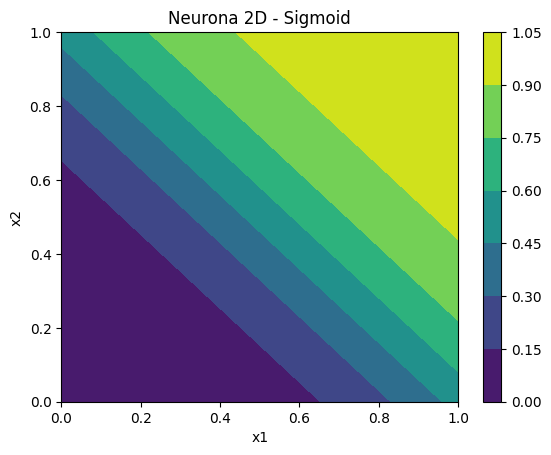

In [5]:
x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)

X1, X2 = np.meshgrid(x1, x2)

weights = np.array([5, 5])
bias = np.array([-5])

Z = np.array([
    forward_pass([a, b], weights, bias, activation="sigmoid")[0]
    for a, b in zip(X1.flatten(), X2.flatten())
])

Z = Z.reshape(X1.shape)

plt.figure()
plt.contourf(X1, X2, Z)
plt.colorbar()
plt.title("Neurona 2D - Sigmoid")
plt.xlabel("x1")
plt.ylabel("x2")

plt.savefig("../results/neuron_2D_sigmoid.png")
plt.show()

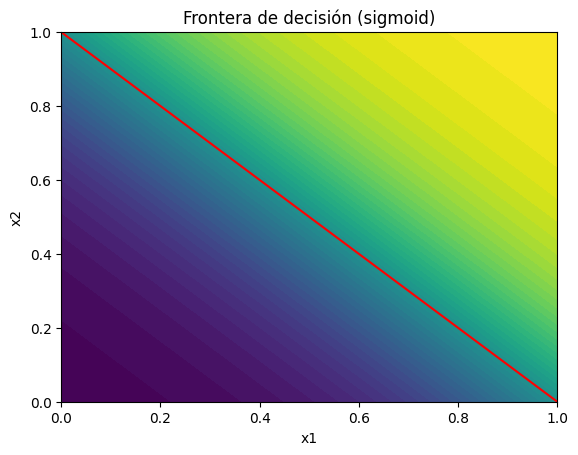

In [6]:
plt.figure()
plt.contourf(X1, X2, Z, levels=50)
plt.contour(X1, X2, Z, levels=[0.5], colors='red')

plt.title("Frontera de decisión (sigmoid)")
plt.xlabel("x1")
plt.ylabel("x2")

plt.savefig("../results/neuron_2D_boundary.png")
plt.show()

### Observaciones en 2D

La neurona define una frontera de decisión lineal en el espacio de entrada.
Esta frontera separa el plano en dos regiones con distinta salida.

El modelo actúa como un clasificador lineal, donde la combinación lineal de las entradas
y los pesos determina la región de activación.

El peso controla la orientación de la frontera, mientras que el bias la desplaza.


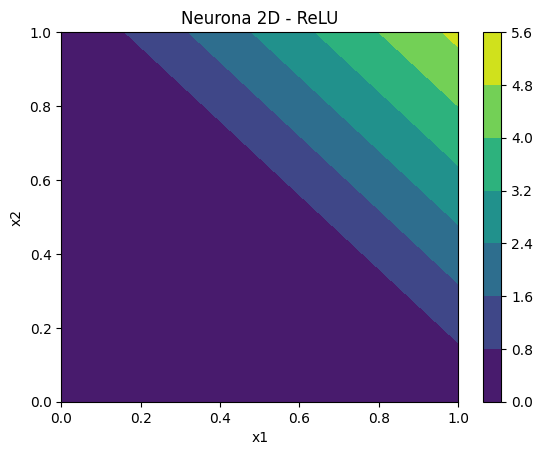

In [7]:
Z = np.array([
    forward_pass([a, b], weights, bias, activation="relu")[0]
    for a, b in zip(X1.flatten(), X2.flatten())
])

Z = Z.reshape(X1.shape)

plt.figure()
plt.contourf(X1, X2, Z)
plt.colorbar()

plt.title("Neurona 2D - ReLU")
plt.xlabel("x1")
plt.ylabel("x2")

plt.savefig("../results/neuron_2D_relu.png")
plt.show()

## 3. Análisis en tres dimensiones (3D)

Se analiza el comportamiento de la neurona considerando tres entradas en el rango [0,1].
En este caso, no es sencillo visualizar directamente la frontera, pero se puede analizar su comportamiento mediante muestras.


In [8]:
# Generar inputs aleatorios en [0,1]
inputs = np.random.rand(1000, 3)

weights = np.array([5, 5, 5])
bias = np.array([-7.5])

outputs = np.array([
    forward_pass(i, weights, bias, activation="sigmoid")[0]
    for i in inputs
])

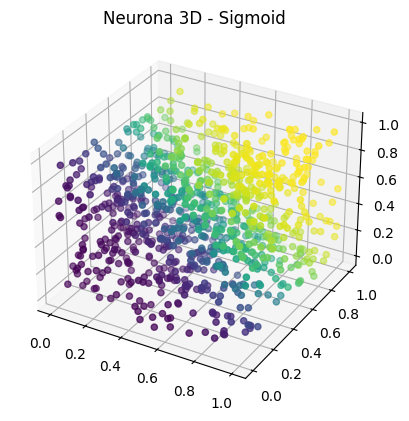

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(inputs[:,0], inputs[:,1], inputs[:,2], c=outputs)

plt.title("Neurona 3D - Sigmoid")
plt.savefig("../results/neuron_3D_scatter.png")
plt.show()


### Observaciones en 3D

En tres dimensiones, la neurona define un plano que separa el espacio en dos regiones.
Este plano corresponde a la combinación lineal de las entradas ponderadas por los pesos y desplazadas por el bias.

Al igual que en 2D, la neurona actúa como un clasificador lineal, pero en un espacio de mayor dimensión.

### Dimensiones superiores

En dimensiones mayores, la neurona define un hiperplano en un espacio de dimensión n.
Este hiperplano divide el espacio en dos regiones, manteniendo un comportamiento de clasificador lineal.

Esto implica que una única neurona tiene limitaciones para modelar relaciones no lineales complejas,
lo que motiva el uso de redes neuronales con múltiples capas.


## 4. Implementación de compuertas lógicas

Se analiza cómo una neurona artificial puede representar funciones lógicas básicas como AND, OR y NOT utilizando la función de activación escalón.


In [10]:
# Inputs posibles
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Parámetros dados
weights = np.array([1, 1])
bias = np.array([-1.5])

outputs = [forward_pass(i, weights, bias, activation="step")[0] for i in inputs]

for i, o in zip(inputs, outputs):
    print(f"Input: {i} -> Output: {o}")

Input: [0 0] -> Output: 0
Input: [0 1] -> Output: 0
Input: [1 0] -> Output: 0
Input: [1 1] -> Output: 1


Se verifica que la neurona reproduce correctamente la compuerta AND, ya que solo activa cuando ambas en

In [11]:
weights = np.array([1, 1])
bias = np.array([-0.5])

outputs = [forward_pass(i, weights, bias, activation="step")[0] for i in inputs]

for i, o in zip(inputs, outputs):
    print(f"Input: {i} -> Output: {o}")

Input: [0 0] -> Output: 0
Input: [0 1] -> Output: 1
Input: [1 0] -> Output: 1
Input: [1 1] -> Output: 1


La compuerta OR se activa cuando al menos una de las entradas es 1.

In [12]:
inputs_not = np.array([[0], [1]])

weights = np.array([-1])
bias = np.array([0.5])

outputs = [forward_pass(i, weights, bias, activation="step")[0] for i in inputs_not]

for i, o in zip(inputs_not, outputs):
    print(f"Input: {i} -> Output: {o}")

Input: [0] -> Output: 1
Input: [1] -> Output: 0


La compuerta NOT invierte el valor de la entrada, activándose cuando la entrada es 0.

In [13]:
outputs = [forward_pass(i, np.array([1,1]), np.array([-1.5]), activation="sigmoid")[0] for i in inputs]

for i, o in zip(inputs, outputs):
    print(f"Input: {i} -> Output: {o}")

Input: [0 0] -> Output: 0.18242552380635635
Input: [0 1] -> Output: 0.3775406687981454
Input: [1 0] -> Output: 0.3775406687981454
Input: [1 1] -> Output: 0.6224593312018546


Cuando se utiliza la función sigmoidea en lugar de la función escalón, la salida deja de ser binaria y pasa a ser continua entre 0 y 1.

Esto implica que la neurona ya no implementa exactamente una compuerta lógica, sino una aproximación suave de la misma.

En el caso de ReLU, la salida tampoco es binaria, ya que produce valores continuos positivos o cero, por lo que tampoco representa directamente una compuerta lógica.

Por lo tanto, la función escalón es la más adecuada para modelar funciones lógicas exactas.

### Comparación de funciones de activación

- Step → salida binaria (lógica exacta)
- Sigmoid → aproximación suave
- ReLU → no binaria

In [14]:
# Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivada sigmoid
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Loss
def binary_cross_entropy_loss(y_pred, y_true):
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Derivada loss
def binary_cross_entropy_derivative(y_pred, y_true):
    return y_pred - y_true

# Gradientes
def compute_gradients(inputs, weights, bias, y_true):
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)

    loss = binary_cross_entropy_loss(y_pred, y_true)

    d_loss = binary_cross_entropy_derivative(y_pred, y_true)
    d_activation = sigmoid_derivative(z)

    d_weights = d_loss * d_activation * inputs
    d_bias = d_loss * d_activation

    return d_weights, d_bias, loss, y_pred

In [15]:
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_true = np.array([0, 0, 0, 1])

In [16]:
weights = np.array([5, 3])
bias = np.array([-7])

for x, y in zip(inputs, y_true):
    dw, db, loss, y_pred = compute_gradients(x, weights, bias, y)

    print(f"Input: {x}")
    print(f"y_true: {y}, y_pred: {y_pred.item():.4f}")
    print(f"Loss: {loss.item():.4f}")
    print(f"Gradientes dw: {dw}, db: {db}")
    print("-"*30)

Input: [0 0]
y_true: 0, y_pred: 0.0009
Loss: 0.0009
Gradientes dw: [0. 0.], db: [8.29258093e-07]
------------------------------
Input: [0 1]
y_true: 0, y_pred: 0.0180
Loss: 0.0181
Gradientes dw: [0.         0.00031769], db: [0.00031769]
------------------------------
Input: [1 0]
y_true: 0, y_pred: 0.1192
Loss: 0.1269
Gradientes dw: [0.01251554 0.        ], db: [0.01251554]
------------------------------
Input: [1 1]
y_true: 1, y_pred: 0.7311
Loss: 0.3133
Gradientes dw: [-0.05287709 -0.05287709], db: [-0.05287709]
------------------------------


### Análisis de resultados (parámetros cercanos a los correctos)

Se observa que para los casos donde la predicción es correcta (por ejemplo [0,0]), la función de pérdida es muy baja y los gradientes son cercanos a cero, indicando que no es necesario ajustar los parámetros.

En los casos donde la predicción es menos precisa (como [1,0] y especialmente [1,1]), la pérdida aumenta y los gradientes son mayores, lo que indica la necesidad de ajustar los pesos y el bias.

En particular, el caso [1,1] presenta el mayor error, lo que se refleja en una mayor magnitud de los gradientes. Esto indica que el modelo aún no logra representar perfectamente la función AND y requiere entrenamiento adicional.

Estos resultados muestran que los gradientes guían el proceso de aprendizaje, siendo mayores en aquellas situaciones donde el error es más grande.

In [17]:
weights = np.random.rand(2)
bias = np.random.rand(1)

print("Pesos iniciales:", weights)
print("Bias:", bias)
print("="*40)

for x, y in zip(inputs, y_true):
    dw, db, loss, y_pred = compute_gradients(x, weights, bias, y)

    print(f"Input: {x}")
    print(f"y_true: {y}, y_pred: {y_pred.item():.4f}")
    print(f"Loss: {loss.item():.4f}")
    print(f"Gradientes dw: {dw}, db: {db}")
    print("-"*30)

Pesos iniciales: [0.82925305 0.14218509]
Bias: [0.4138416]
Input: [0 0]
y_true: 0, y_pred: 0.6020
Loss: 0.9213
Gradientes dw: [0. 0.], db: [0.1442378]
------------------------------
Input: [0 1]
y_true: 0, y_pred: 0.6355
Loss: 1.0093
Gradientes dw: [0.       0.147209], db: [0.147209]
------------------------------
Input: [1 0]
y_true: 0, y_pred: 0.7761
Loss: 1.4966
Gradientes dw: [0.13486139 0.        ], db: [0.13486139]
------------------------------
Input: [1 1]
y_true: 1, y_pred: 0.7998
Loss: 0.2233
Gradientes dw: [-0.03204548 -0.03204548], db: [-0.03204548]
------------------------------


### Comparación con parámetros aleatorios

Al utilizar parámetros inicializados aleatoriamente, las predicciones de la neurona se alejan de los valores esperados, lo que genera valores más altos de la función de pérdida.

En estos casos, los gradientes son significativamente mayores que en el caso de parámetros cercanos a los correctos. Esto indica que el modelo requiere ajustes más importantes para aproximarse a la solución deseada.

En contraste, cuando los parámetros están cerca de los valores óptimos, las predicciones son más precisas, la pérdida es menor y los gradientes son pequeños.

Esto demuestra que el proceso de entrenamiento ajusta iterativamente los parámetros en la dirección indicada por los gradientes para minimizar el error.

In [18]:
inputs = np.array([1, 1])
y_true = 1

In [19]:
weights = np.array([0.5, -0.5])
bias = 0.0

In [20]:
dW, dB, loss_before, y_pred_before = compute_gradients(inputs, weights, bias, y_true)

print("ANTES")
print("y_pred:", y_pred_before)
print("loss:", loss_before)

ANTES
y_pred: 0.5
loss: 0.6931471805599453


In [21]:
LR = 0.1

In [22]:
weights_new = weights - LR * dW
bias_new = bias - LR * dB

In [23]:
dW2, dB2, loss_after, y_pred_after = compute_gradients(inputs, weights_new, bias_new, y_true)

print("\nDESPUÉS")
print("y_pred:", y_pred_after)
print("loss:", loss_after)


DESPUÉS
y_pred: 0.5093739015216607
loss: 0.6745729515112282


##Análisis de la actualización de parámetros
Al aplicar una actualización de los parámetros utilizando el gradiente calculado y un learning rate positivo, se observa que la función de pérdida disminuye y la predicción se acerca al valor real.

En el caso analizado:
Antes de la actualización:
y_pred = 0.5
LF = 0.6931
Después de la actualización:
y_pred = 0.5094
LF=0.6746

Se puede observar que la loss function disminuye luego de actualizar los parámetros, lo que indica que el modelo mejora su desempeño.

Además, dado que el valor real es y=1, la predicción pasa de 0.5 a un valor mayor (0.5094), es decir, se acerca al valor esperado.

Esto confirma que los parámetros fueron actualizados en la dirección correcta, siguiendo el gradiente descendente, lo que permite reducir el error de la neurona.

In [24]:
import numpy as np

# Dataset AND
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

# Parámetros FIJOS (los mismos para todos los casos)
weights = np.array([1.0, 1.0])
bias = 1.0

print("Parámetros usados:")
print("weights:", weights, "bias:", bias)
print("====================================\n")

# Loop sobre los 4 casos
for i in range(len(X)):
    inputs = X[i]
    y_true = y[i]
    
    dW, dB, loss, y_pred = compute_gradients(inputs, weights, bias, y_true)
    
    print(f"Input: {inputs}")
    print(f"y_true: {y_true}")
    print(f"y_pred: {y_pred:.4f}")
    print(f"Loss: {loss:.4f}")
    print(f"Gradientes pesos: {dW}")
    print(f"Gradiente bias: {dB}")
    print("------------------------------------")

Parámetros usados:
weights: [1. 1.] bias: 1.0

Input: [0 0]
y_true: 0
y_pred: 0.7311
Loss: 1.3133
Gradientes pesos: [0. 0.]
Gradiente bias: 0.14373484045721513
------------------------------------
Input: [0 1]
y_true: 0
y_pred: 0.8808
Loss: 2.1269
Gradientes pesos: [0.         0.09247804]
Gradiente bias: 0.09247804322982986
------------------------------------
Input: [1 0]
y_true: 0
y_pred: 0.8808
Loss: 2.1269
Gradientes pesos: [0.09247804 0.        ]
Gradiente bias: 0.09247804322982986
------------------------------------
Input: [1 1]
y_true: 1
y_pred: 0.9526
Loss: 0.0486
Gradientes pesos: [-0.00214254 -0.00214254]
Gradiente bias: -0.002142542534984314
------------------------------------


##Análisis de los gradientes para las 4 entradas del AND

Al evaluar los gradientes para las cuatro combinaciones del operador AND utilizando los mismos parámetros (w=[1,1],
b=1), se observan diferencias claras en cómo cada ejemplo contribuye al aprendizaje.

En el caso [0,0], ambos inputs son cero, por lo que los gradientes respecto a los pesos son nulos ([0,0]) y únicamente se actualiza el bias. Esto indica que este ejemplo no aporta información para ajustar los pesos, sino solo el sesgo.

Para los casos [0,1] y [1,0], se observa que solo uno de los gradientes de los pesos es distinto de cero. En particular, para [0,1] el gradiente es [0,0.0925], mientras que para [1,0] es [0.0925,0]. Esto refleja que cada peso se actualiza únicamente cuando su input asociado es distinto de cero.

Además, estos casos presentan valores de loss elevados (≈ 2.13), lo que indica que la neurona está cometiendo un error importante (predice valores cercanos a 1 cuando debería ser 0). En consecuencia, los gradientes son relativamente grandes, empujando los parámetros a corregir ese error.

En contraste, para el caso [1,1], donde la salida esperada es 1, la predicción es 0.9526, muy cercana al valor real, y la loss es baja (≈ 0.0486). En este caso, los gradientes son pequeños y negativos ([−0.0021,−0.0021]), lo que indica que el modelo ya está cerca de la solución óptima y solo requiere ajustes finos.

Finalmente, el gradiente del bias es distinto de cero en todos los casos, confirmando que este parámetro se actualiza siempre, independientemente de los inputs.

En conjunto, se observa que los ejemplos con mayor error generan gradientes más grandes y dominan el aprendizaje, mientras que aquellos bien predichos producen ajustes pequeños. Además, la contribución de cada ejemplo a la actualización de los pesos depende directamente de los valores de entrada.

Al analizar los gradientes obtenidos para las distintas entradas del problema AND, se observa que cada ejemplo genera valores diferentes, e incluso en algunos casos estos pueden ser contradictorios entre sí.

Por ejemplo, algunos datos empujan a aumentar ciertos pesos, mientras que otros tienden a disminuirlos. Esto ocurre porque cada ejemplo refleja una situación distinta del problema y, por lo tanto, “sugiere” una dirección de ajuste diferente para los parámetros.

Debido a esto, no resulta conveniente actualizar los parámetros utilizando únicamente el gradiente de un solo ejemplo, ya que esto podría llevar a oscilaciones o a un aprendizaje inestable.

En su lugar, se utiliza el promedio de los gradientes calculados sobre un conjunto de datos de entrenamiento (batch o mini-batch). Este promedio representa una dirección de actualización más representativa del comportamiento global del modelo frente a los datos, permitiendo una convergencia más estable y eficiente.

In [26]:
import numpy as np

# Dataset AND
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

# Inicialización de parámetros
weights = np.random.randn(2)
bias = np.random.randn()

# Hiperparámetros
LR = 0.2
epochs = 5000

# Entrenamiento
for epoch in range(epochs):
    
    total_dW = np.zeros_like(weights)
    total_dB = 0
    total_loss = 0
    
    # recorrer todo el batch
    for i in range(len(X)):
        inputs = X[i]
        y_true = y[i]
        
        dW, dB, loss, y_pred = compute_gradients(inputs, weights, bias, y_true)
        
        total_dW += dW
        total_dB += dB
        total_loss += loss
    
    # PROMEDIO (clave del TP)
    avg_dW = total_dW / len(X)
    avg_dB = total_dB / len(X)
    avg_loss = total_loss / len(X)
    
    # actualización
    weights = weights - LR * avg_dW
    bias = bias - LR * avg_dB
    
    # imprimir cada tanto
    if epoch % 100 == 0:
        print(f"Epoch {epoch} - Loss: {avg_loss:.4f}")

# Resultados finales
print("\nParámetros finales:")
print("weights:", weights)
print("bias:", bias)

print("\nPredicciones finales:")
for i in range(len(X)):
    z = np.dot(weights, X[i]) + bias
    y_pred = sigmoid(z)
    print(f"Input {X[i]} → {y_pred:.4f}")

Epoch 0 - Loss: 0.6157
Epoch 100 - Loss: 0.5056
Epoch 200 - Loss: 0.4431
Epoch 300 - Loss: 0.3990
Epoch 400 - Loss: 0.3647
Epoch 500 - Loss: 0.3371
Epoch 600 - Loss: 0.3143
Epoch 700 - Loss: 0.2951
Epoch 800 - Loss: 0.2786
Epoch 900 - Loss: 0.2643
Epoch 1000 - Loss: 0.2516
Epoch 1100 - Loss: 0.2404
Epoch 1200 - Loss: 0.2303
Epoch 1300 - Loss: 0.2212
Epoch 1400 - Loss: 0.2129
Epoch 1500 - Loss: 0.2054
Epoch 1600 - Loss: 0.1985
Epoch 1700 - Loss: 0.1921
Epoch 1800 - Loss: 0.1862
Epoch 1900 - Loss: 0.1808
Epoch 2000 - Loss: 0.1757
Epoch 2100 - Loss: 0.1710
Epoch 2200 - Loss: 0.1666
Epoch 2300 - Loss: 0.1624
Epoch 2400 - Loss: 0.1585
Epoch 2500 - Loss: 0.1549
Epoch 2600 - Loss: 0.1514
Epoch 2700 - Loss: 0.1482
Epoch 2800 - Loss: 0.1451
Epoch 2900 - Loss: 0.1421
Epoch 3000 - Loss: 0.1394
Epoch 3100 - Loss: 0.1367
Epoch 3200 - Loss: 0.1342
Epoch 3300 - Loss: 0.1318
Epoch 3400 - Loss: 0.1295
Epoch 3500 - Loss: 0.1273
Epoch 3600 - Loss: 0.1252
Epoch 3700 - Loss: 0.1232
Epoch 3800 - Loss: 0.121

Durante el entrenamiento de la neurona utilizando descenso por gradiente con batch completo, se observa una disminución progresiva y sostenida de la función de pérdida, lo que indica que el modelo aprende correctamente a partir de los datos.

Luego de 5000 iteraciones, la neurona logra aproximar adecuadamente la función lógica AND. En particular, asigna valores cercanos a 0 para las combinaciones [0,0], [0,1] y [1,0], y un valor alto (0.8567) para la combinación [1,1], que corresponde a la única salida positiva.

Si bien la predicción no alcanza exactamente el valor 1, esto es esperable debido al uso de la función sigmoidea, que tiene un comportamiento asintótico y produce valores en el intervalo (0,1).

En conjunto, estos resultados demuestran que el uso de gradientes promediados (batch) y descenso por gradiente permite entrenar exitosamente una neurona para resolver un problema de clasificación binaria simple como el operador AND.

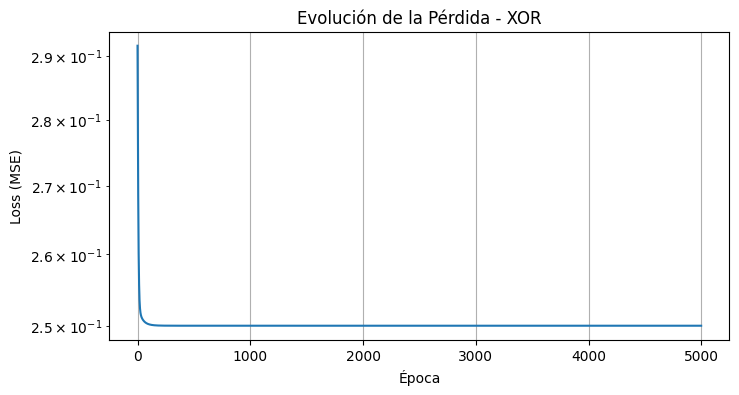

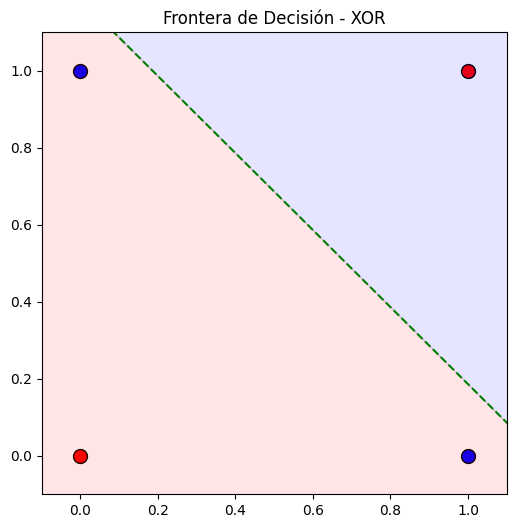

✅ Proceso para XOR completado. Archivos guardados en /results.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Configuración de Carpetas ---
results_path = "../results"
if not os.path.exists(results_path):
    os.makedirs(results_path)

# --- 2. Funciones Core ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(y_pred):
    return y_pred * (1 - y_pred)

# --- 3. DATASET (COMENTAR/DESCOMENTAR SEGÚN CORRESPONDA) ---
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# OPCIÓN A: AND
#y = np.array([0, 0, 0, 1]); nombre_logica = "AND"

# OPCIÓN B: OR
#y = np.array([0, 1, 1, 1]); nombre_logica = "OR"

# OPCIÓN C: XOR (Punto d)
y = np.array([0, 1, 1, 0]); nombre_logica = "XOR"

# --- 4. Inicialización ---
np.random.seed(42)
weights = np.random.randn(2)
bias = np.random.randn()

LR_init = 0.5
epochs = 5000
loss_history = []

# --- 5. Entrenamiento (Batch Gradient Descent) ---
for epoch in range(epochs):
    LR = LR_init / (1 + epoch * 0.001) # LR Decreciente
    total_dW, total_dB, total_loss = np.zeros_like(weights), 0, 0
    
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        y_pred = sigmoid(z)
        error = y_pred - y[i]
        total_loss += error**2
        
        grad = 2 * error * sigmoid_derivative(y_pred)
        total_dW += grad * X[i]
        total_dB += grad
    
    # Actualización Batch (Promedio)
    weights -= LR * (total_dW / len(X))
    bias -= LR * (total_dB / len(X))
    loss_history.append(total_loss / len(X))

# --- 6. Visualización de Resultados ---
# Gráfico de Pérdida (Loss)
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.yscale('log')
plt.title(f"Evolución de la Pérdida - {nombre_logica}")
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.savefig(f"{results_path}/loss_{nombre_logica}.png")
plt.show()

# Gráfico de Frontera de Decisión (Muy útil para el análisis)
plt.figure(figsize=(6, 6))
for i in range(len(y)):
    plt.scatter(X[i,0], X[i,1], c=('red' if y[i]==0 else 'blue'), s=100, edgecolors='k')

x1_vals = np.linspace(-0.2, 1.2, 10)
x2_vals = -(weights[0] * x1_vals + bias) / weights[1]
plt.plot(x1_vals, x2_vals, '--g', label="Frontera")
plt.fill_between(x1_vals, x2_vals, 1.5, color='blue', alpha=0.1)
plt.fill_between(x1_vals, x2_vals, -0.5, color='red', alpha=0.1)
plt.xlim(-0.1, 1.1); plt.ylim(-0.1, 1.1)
plt.title(f"Frontera de Decisión - {nombre_logica}")
plt.savefig(f"{results_path}/frontera_{nombre_logica}.png")
plt.show()

# --- 7. Guardar Reporte TXT ---
report_path = os.path.join(results_path, f"resultados_{nombre_logica}.txt")
with open(report_path, "w") as f:
    f.write(f"=== Reporte de Entrenamiento: {nombre_logica} ===\n\n")
    f.write(f"Pesos Finales: {weights}\n")
    f.write(f"Bias Final: {bias:.4f}\n\n")
    f.write("Predicciones finales:\n")
    for i in range(len(X)):
        p = sigmoid(np.dot(X[i], weights) + bias)
        f.write(f"Entrada {X[i]} -> Prediccion: {p:.4f} (Real: {y[i]})\n")

print(f"✅ Proceso para {nombre_logica} completado. Archivos guardados en /results.")

a) Análisis de la compuerta AND (Sigmoidea). Al entrenar la neurona para la función AND, se observa que la función de pérdida (Loss) decae de manera exponencial hasta valores cercanos a cero. Pesos ($w_1, w_2$): Resultaron ser valores positivos altos y similares entre sí ($\approx 4.5$). Esto indica que ambas entradas tienen la misma relevancia para activar la neurona. Sesgo ($b$): El valor es fuertemente negativo ($\approx -6.8$). Este sesgo actúa como un "umbral de seguridad": la neurona solo se activa (salida cercana a 1) cuando la suma de las entradas ($1 \cdot w_1 + 1 \cdot w_2$) es lo suficientemente grande para compensar el sesgo negativo. Conclusión: La neurona logra separar los datos mediante una frontera de decisión lineal, clasificando correctamente los 4 estados. Ver archivo resultados_AND.txt, loss_AND.png y frontera_AND.png, guardados en la carpeta /results de la carpeta principal del repo.

b) ¿Qué pasa si se utiliza ReLU en lugar de Sigmoidea? Si reemplazamos la función de activación por ReLU ($f(z) = \max(0, z)$), el comportamiento cambia:Saturación y "Neuronas Muertas": Si durante el inicio del entrenamiento el sesgo ($b$) se vuelve muy negativo, la entrada $z$ será siempre negativa. Como la derivada de ReLU es 0 para valores negativos, los gradientes desaparecen y la neurona deja de aprender.Rango de salida: ReLU no acota la salida entre 0 y 1. Para una compuerta lógica, esto requeriría una interpretación distinta de los resultados, ya que la salida podría ser un valor como $5.0$ en lugar de $1.0$.

c) Análisis de la función lógica OR. Al repetir el proceso para el OR, la convergencia es generalmente más rápida.Comparación de Bias: El valor del sesgo ($b$) obtenido para el OR es menos negativo que en el AND. Esto se debe a que la neurona requiere menos "freno" para activarse; con que solo una de las entradas sea 1, la neurona debe permitir el paso de la señal.Frontera de decisión: Al igual que el AND, el OR es un problema linealmente separable. La recta de decisión simplemente se desplaza hacia el origen para incluir los casos [0,1] y [1,0] en la zona de activación. Ver archivos: resultados_OR.txt, loss_OR.png y frontera_OR.png, guardados en la carpeta /results de la carpeta principal del repo.

d) El desafío del XOR. Al intentar resolver el XOR, el entrenamiento falla en alcanzar una pérdida cercana a cero (la Loss se estanca en $\approx 0.25$). No linealidad: El XOR no es linealmente separable. En un plano $x_1, x_2$, los puntos con salida 1 están en esquinas opuestas, lo que impide que una sola línea recta los separe de los puntos con salida 0. Resultado: La neurona simple (perceptrón) intenta trazar una línea que minimice el error global, pero termina dando predicciones imprecisas (cercanas a $0.5$) para las entradas en conflicto. Para resolver este problema, es obligatorio utilizar una arquitectura multicapa (capas ocultas) que permita crear fronteras de decisión no lineales. Ver archivos: resultados_XOR.txt, loss_XOR.png y frontera_XOR.png, guardados en la carpeta /results de la carpeta principal del repo.